## Linear Regression

We will use linear regression as our baseline model in predicting observation counts of American goldfinch. First, we will use all the available variables in th regression. Then, we will remove unnecessary variables by using the F-statistic and the Variance Inflation Factors. We will also add harmonic variables to attempt to address seasonality in the data. The residual plot for linear regression indicates that there are many outliers in the data. To address this issue, we will use Lasso and Ridge regularization to decrease the variance of our model.

### Importing the necessary packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import scipy.stats
import io

from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

import statsmodels.api as sm

### Baseline linear regression model

First, we will create some helper functions that will help us create the cross-validation split and evaluate the cross-validation error.

In [7]:
def getCrossValSplit(Features, Responses, Dates):

    ## Create a 4-fold cross validation split. Each validation set will contain 3 months worth of data
    
    validationCutoff5 = (np.datetime64(datetime.datetime(2019,11,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    validationCutoff4 = (np.datetime64(datetime.datetime(2019,9,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    validationCutoff3 = (np.datetime64(datetime.datetime(2019,7,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    validationCutoff2 = (np.datetime64(datetime.datetime(2019,5,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    validationCutoff1 = (np.datetime64(datetime.datetime(2019,3,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')

    validationCutoffs = [validationCutoff1, validationCutoff2, validationCutoff3, validationCutoff4, validationCutoff5]
    trainingDates = [Dates[Dates < validationCutoffs[i]] for i in range(4)]
    validationDates = [Dates[(Dates < validationCutoffs[i+1]) & (Dates >= validationCutoffs[i])] for i in range(4)]
    trainingInds = list(map(lambda x: x.index, trainingDates))
    validationInds = list(map(lambda x: x.index, validationDates))
    
    trainXs = [Features.loc[trainingInds[i]] for i in range(4)]
    trainYs = [Responses.loc[trainingInds[i]] for i in range(4)]
    validXs = [Features.loc[validationInds[i]] for i in range(4)]
    validYs = [Responses.loc[validationInds[i]] for i in range(4)]


    return trainXs, trainYs, validXs, validYs, trainingDates, validationDates


def getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs):

    ## Compute the cross validation error 
    
    MSEs = np.zeros(4)

    for i in range(4):
        trainX, trainY, validX, validY = trainXs[i], trainYs[i], validXs[i], validYs[i]
        model = sm.OLS(trainY, trainX)
        results = model.fit()
        preds = results.predict(validX)
        MSEs[i] = np.mean(np.power(validY.values-preds, 2))
    
    return np.mean(MSEs)


Our baseline model is linear regression with all the variables.

In [9]:
data = pd.read_csv("Data/TrainData.csv")

cols = [
    "IBA CODE",
    "BCR CODE",
    "USFWS CODE",
    "OBSERVATION TYPE_Area",
    "OBSERVATION TYPE_Banding",
    "OBSERVATION TYPE_Historical",
    "OBSERVATION TYPE_Incidental",
    "OBSERVATION TYPE_Nocturnal Flight Call Count",
    "OBSERVATION TYPE_Stationary",
    "OBSERVATION TYPE_Traveling"
]

for col in cols:
    data[col] = data[col].astype(int)

data = data.drop(["OBSERVATION TYPE_eBird Pelagic Protocol"], axis = 1)
data["INTERCEPT"] = np.ones(len(data))

Dates = data["OBSERVATION DATE"]
X = data.drop("OBSERVATION COUNT", axis = 1)
Y = data["OBSERVATION COUNT"]

In [10]:
trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)

print(f"The cross validation error for the basline model is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error for the basline model is 43.27128205589792


### Improvements on the baseline model

First, we will look at the regression results summary to see what the $R^2$ statistic is and to see if there are any unnecessary variables.

In [13]:
trainX = trainXs[-1]
trainY = trainYs[-1]

linearModel = sm.OLS(trainY, trainX)
results = linearModel.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      OBSERVATION COUNT   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     1115.
Date:                Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:28:18   Log-Likelihood:            -2.3179e+06
No. Observations:              703967   AIC:                         4.636e+06
Df Residuals:                  703949   BIC:                         4.636e+06
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
IBA CODE                                        -0.2009      0.021     -9.362      0.000      -0.243      -0.159
BCR CODE                                         0.3994      0.047      8.432      0.000       0.307       0.492
USFWS CODE                                      -0.2687      0.061     -4.388      0.000      -0.389      -0.149
LATITUDE                                         0.1001      0.005     20.278      0.000       0.090       0.110
LONGITUDE                                        0.0656      0.004     17.103      0.000       0.058       0.073
OBSERVATION DATE                                -0.0010   4.45e-05    -22.240      0.000      -0.001      -0.001
TIME OBSERVATIONS STARTED                       -0.1295      0.002    -62.808      0.000      -0.134      -0.125
DURATION MINUTES                                 0.0089   8.78e-05    101.478      0.000       0.009       0.009
PRCP                                             0.0003      0.000      2.254      0.024    3.63e-05       0.001
SNOW                                             0.0163      0.001     23.676      0.000       0.015       0.018
TOBS                                             0.0086      0.001     10.300      0.000       0.007       0.010
OBSERVATION TYPE_Area                            3.5985      3.258      1.104      0.269      -2.787       9.984
OBSERVATION TYPE_Banding                         0.1346      3.272      0.041      0.967      -6.279       6.548
OBSERVATION TYPE_Historical                      1.4772      3.260      0.453      0.650      -4.912       7.866
OBSERVATION TYPE_Incidental                   3.419e-16   1.82e-15      0.188      0.851   -3.22e-15    3.91e-15
OBSERVATION TYPE_Nocturnal Flight Call Count     0.5388      3.474      0.155      0.877      -6.269       7.347
OBSERVATION TYPE_Stationary                      1.6724      3.256      0.514      0.608      -4.710       8.055
OBSERVATION TYPE_Traveling                       1.5192      3.256      0.467      0.641      -4.863       7.901
INTERCEPT                                        2.5600      3.277      0.781      0.435      -3.863       8.983
==============================================================================
Omnibus:                  2727532.910   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.000   Jarque-Bera (JB):   13278739712718.000
Skew:                          91.868   Prob(JB):                         0.00
Kurtosis:                   21279.084   Cond. No.                     2.82e+21
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenv

Some of the one-hot encoded variables for the label OBSERVATION TYPE seem unnecessary. We will do a null hypothesis testing to ask whether or not the regression coefficients for the variables with $p$-values higher than a certain threshold are 0. The $F$-statistic that we will use is
$$
F = \frac{(RSS_0 - RSS)/q}{RSS/(n-p-1)},
$$
where $n$ is the number of observations, $p$ is the total number of variables (not including the intercept), $q$ is the number of variables to be omitted, $RSS$ is the sum of squared residuals for the full model, and $RSS_0$ is the sum of squared residuals for the model after omitting the $q$ variables.

In [15]:
def getBadColsLinReg(X,Y,pValue):

    ## Return a list of column labels with p-values corresponding to the t-statistic greater than pValue
    
    model = sm.OLS(Y, X)
    res = linearModel.fit()
    coeffs = pd.read_csv(io.StringIO(res.summary().tables[1].as_csv()))
    badCols = list(coeffs[coeffs["P>|t| "] > pValue].iloc[:,0].values)
    badCols = list(map(lambda x : x.rstrip(), badCols))
    if "INTERCEPT" in badCols:
        badCols.remove("INTERCEPT")
    return badCols



def computeOmissionF(X,Y, badCols):

    ## compute the F-statistic and return the corresponding p-value
    
    n = len(X)
    p = len(X.columns)-1
    q = len(badCols)
    
    temp = X.drop(badCols, axis = 1)

    model1 = sm.OLS(Y,X)
    res1 = model1.fit()
    RSS = res1.ssr
    
    model2 = sm.OLS(Y, temp)
    res2 = model2.fit()
    RSS0 = res2.ssr
    
    F = ((RSS0 - RSS)/q)/(RSS/(n-p-1))
    
    return scipy.stats.f.pdf(F, q,n-p-1)

In [16]:
bCols = getBadColsLinReg(trainX, trainY, 0.8)

print(f"The column labels with high p-values are\n{bCols}.\nThe F-statistic has a p-value of {computeOmissionF(trainX, trainY, bCols)}")

The column labels with high p-values are
['OBSERVATION TYPE_Banding', 'OBSERVATION TYPE_Incidental', 'OBSERVATION TYPE_Nocturnal Flight Call Count'].
The F-statistic has a p-value of 0.3705907379963228


We cannot reject the null hypothesis that "OBSERVATION TYPE_Banding" and "OBSERVATION TYPE_Nocturnal Flight Call Count" are unrelated to the response variable. So we will omit these variables.

In [18]:
X = data.drop(["OBSERVATION COUNT"] + bCols, axis = 1)
Y = data["OBSERVATION COUNT"]

trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y,Dates)

print(f"The cross validation error after dropping the unnecessary variables is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error after dropping the unnecessary variables is 43.27069871181494


Let's see how thre regression results summary has changed.

In [20]:
trainX = trainXs[-1]
trainY = trainYs[-1]

linearModel = sm.OLS(trainY, trainX)
results = linearModel.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      OBSERVATION COUNT   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     1264.
Date:                Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:28:23   Log-Likelihood:            -2.3179e+06
No. Observations:              703967   AIC:                         4.636e+06
Df Residuals:                  703951   BIC:                         4.636e+06
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
IBA CODE                       -0.2010      0.021     -9.363      0.000      -0.243      -0.159
BCR CODE                        0.3994      0.047      8.432      0.000       0.307       0.492
USFWS CODE                     -0.2688      0.061     -4.390      0.000      -0.389      -0.149
LATITUDE                        0.1001      0.005     20.277      0.000       0.090       0.110
LONGITUDE                       0.0656      0.004     17.102      0.000       0.058       0.073
OBSERVATION DATE               -0.0010   4.45e-05    -22.240      0.000      -0.001      -0.001
TIME OBSERVATIONS STARTED      -0.1295      0.002    -62.807      0.000      -0.134      -0.125
DURATION MINUTES                0.0089   8.78e-05    101.489      0.000       0.009       0.009
PRCP                            0.0003      0.000      2.254      0.024    3.63e-05       0.001
SNOW                            0.0163      0.001     23.677      0.000       0.015       0.018
TOBS                            0.0086      0.001     10.301      0.000       0.007       0.010
OBSERVATION TYPE_Area           3.4384      0.330     10.404      0.000       2.791       4.086
OBSERVATION TYPE_Historical     1.3171      0.346      3.808      0.000       0.639       1.995
OBSERVATION TYPE_Stationary     1.5123      0.311      4.856      0.000       0.902       2.123
OBSERVATION TYPE_Traveling      1.3591      0.311      4.367      0.000       0.749       1.969
INTERCEPT                       2.7199      0.486      5.602      0.000       1.768       3.671
==============================================================================
Omnibus:                  2727533.368   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.000   Jarque-Bera (JB):   13278740675432.162
Skew:                          91.868   Prob(JB):                         0.00
Kurtosis:                   21279.085   Cond. No.                     3.48e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.48e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Second, we will use VIF to get drop highly collinear variables. We compute the VIF for each variable, and drop the variable with the highest VIF if the VIF is above a certain theshold. We repeat this process until all the VIFs are below the chosen threshold.

In [22]:
def getHighVIFCols(X, threshold):

    ## Return the column labels whose VIFs are above the given threshold
    
    temp = X.drop("INTERCEPT", axis = 1)
    vals = [VIF(temp, i) for i in range(len(temp.columns))]
    vif = pd.DataFrame({'vif':vals}, index = temp.columns)
    return vif[vif["vif"] > threshold]


def dropHighVIFCols(X,Y,threshold):

    ## Drop the highly collinear variables one-by-one, and record the change in R^2 at each step
    
    droppedCols = []
    scores = []

    cols = getHighVIFCols(X,threshold)
    temp = X
    
    while len(cols) != 0:
        col = cols["vif"].idxmax()
        temp = temp.drop(col, axis = 1)
        model = sm.OLS(Y, X)
        res = model.fit()
        score = res.rsquared
        droppedCols.append(col)
        scores.append(score)
        cols = getHighVIFCols(temp,threshold)

    return droppedCols, scores
    

Before we compute VIFs, we will check for variables with sample deviation very close to zero (there is a divide by zero error if we keep those variables)

In [24]:
noInfoCols = []

for col in trainX.columns:
    if col == "INTERCEPT":
        continue
    if np.std(trainX[col]) == 0:
        noInfoCols.append(col)

print(f"The columns with zero sample deviation are\n{noInfoCols}")

The columns with zero sample deviation are
[]


In [25]:
X = data.drop(["OBSERVATION COUNT"] + bCols + noInfoCols, axis = 1)
Y = data["OBSERVATION COUNT"]

trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y,Dates)

trainX = trainXs[-1]
trainY = trainYs[-1]

In [26]:
collinCols, scores = dropHighVIFCols(trainX, trainY, 10)

print(f"The columns with high VIFs are\n{collinCols}.\nThe R^2 scores after dropping the respective columns are\n{scores}")

The columns with high VIFs are
['LONGITUDE', 'LATITUDE', 'BCR CODE', 'TIME OBSERVATIONS STARTED'].
The R^2 scores after dropping the respective columns are
[0.026223447151317636, 0.026223447151317636, 0.026223447151317636, 0.026223447151317636]


Let's look at the change in cross validation error after we drop the collinear variables

In [28]:
X = data.drop(["OBSERVATION COUNT"] + bCols + noInfoCols + collinCols, axis = 1)

trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y,Dates)
print(f"The cross validation error after dropping the collinear variables is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error after dropping the collinear variables is 43.554441208084484


Third, we will check to see if there is any correlation/seasonality among the error terms.

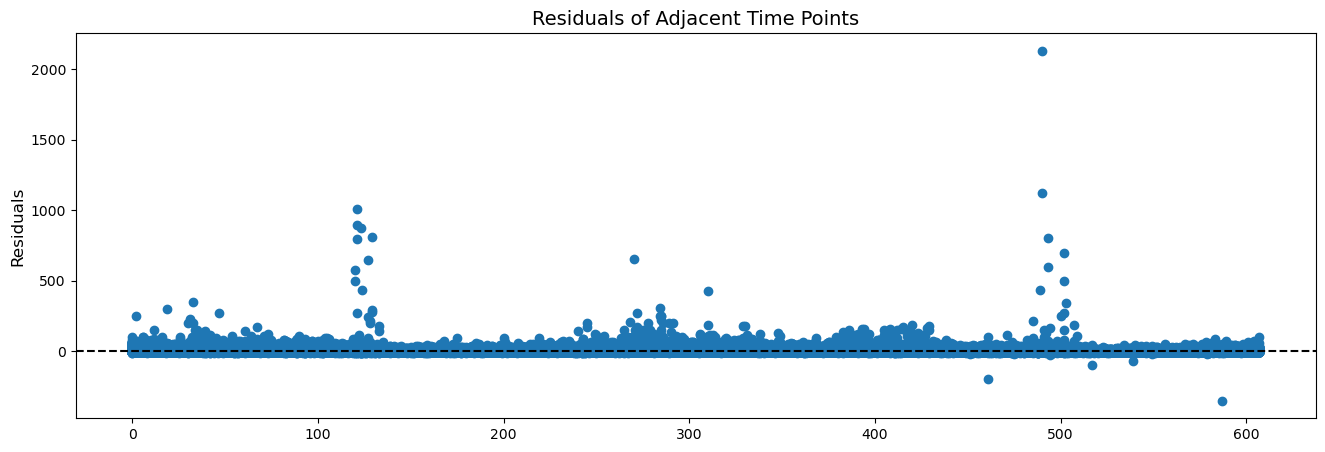

In [30]:
trainX = trainXs[-1]
trainY = trainYs[-1]

model = sm.OLS(trainY, trainX)
res = model.fit()
residuals = res.resid

fig, ax = plt.subplots(1,1,figsize = (16,5))

ax.scatter(trainDates[-1], residuals)
ax.axhline(0,c='k', ls = '--')
ax.set_ylabel("Residuals", fontsize=12)

ax.set_title(f"Residuals of Adjacent Time Points", fontsize=14)


plt.show()

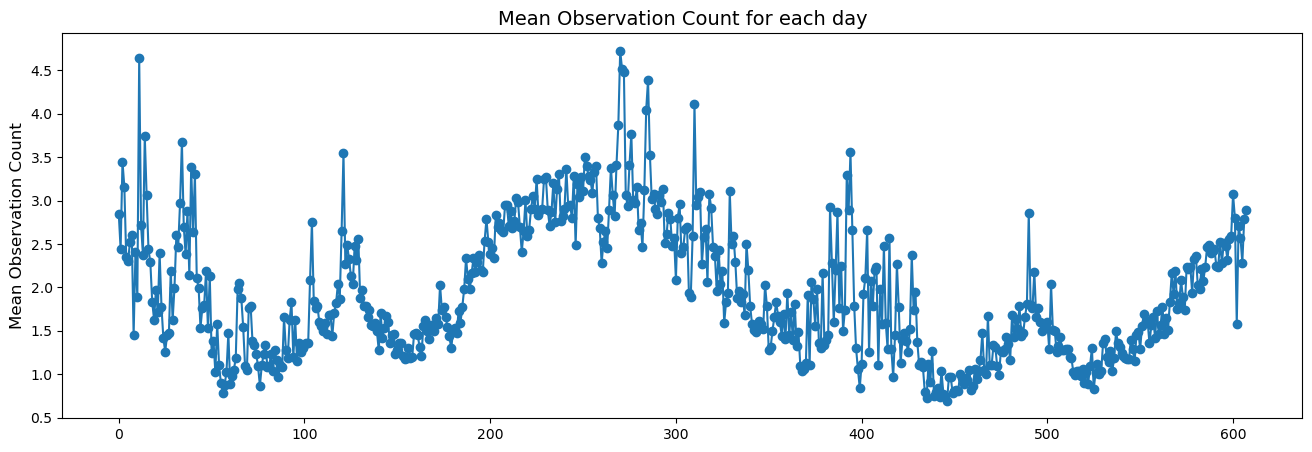

In [31]:
datedY = pd.concat([trainDates[-1], trainYs[-1]], axis=1)
datedMean = datedY.groupby(by = "OBSERVATION DATE").mean()

fig, ax = plt.subplots(1,1,figsize = (16,5))

ax.plot(np.arange(len(datedMean)), datedMean, '-o')
ax.set_ylabel("Mean Observation Count", fontsize=12)

ax.set_title(f"Mean Observation Count for each day", fontsize=14)


plt.show()

The data exhibits seasonality. We will try to account for this by adding sin and cos variables with period equal to 365.

In [33]:
for j in range(5):
    X["SIN" + str(j+1)] = np.sin(data["OBSERVATION DATE"].to_numpy()*2*np.pi*(j+1)/365)
    X["COS" + str(j+1)] = np.cos(data["OBSERVATION DATE"].to_numpy()*2*np.pi*(j+1)/365)

    trainXs, trainYs, validXs, validYs, _, _ = getCrossValSplit(X,Y,Dates)
    print(f"The mean square error when including {j+1} frequencies is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The mean square error when including 1 frequencies is 42.822639427357814
The mean square error when including 2 frequencies is 42.777360972347
The mean square error when including 3 frequencies is 42.73443107509227
The mean square error when including 4 frequencies is 42.740173060426756
The mean square error when including 5 frequencies is 42.73545841012579


There is a big improvement when we add 1 frequency, but not much improvement when we add more frequencies.

In [35]:
X = data.drop(["OBSERVATION COUNT"] + bCols + noInfoCols + collinCols, axis = 1)

X["SIN"] = np.sin(data["OBSERVATION DATE"].to_numpy()*2*np.pi*(j+1)/365)
X["COS"] = np.cos(data["OBSERVATION DATE"].to_numpy()*2*np.pi*(j+1)/365)

trainXs, trainYs, validXs, validYs, _, _ = getCrossValSplit(X,Y,Dates)

Finally, we will look at the residual plot to see if there are outliers.

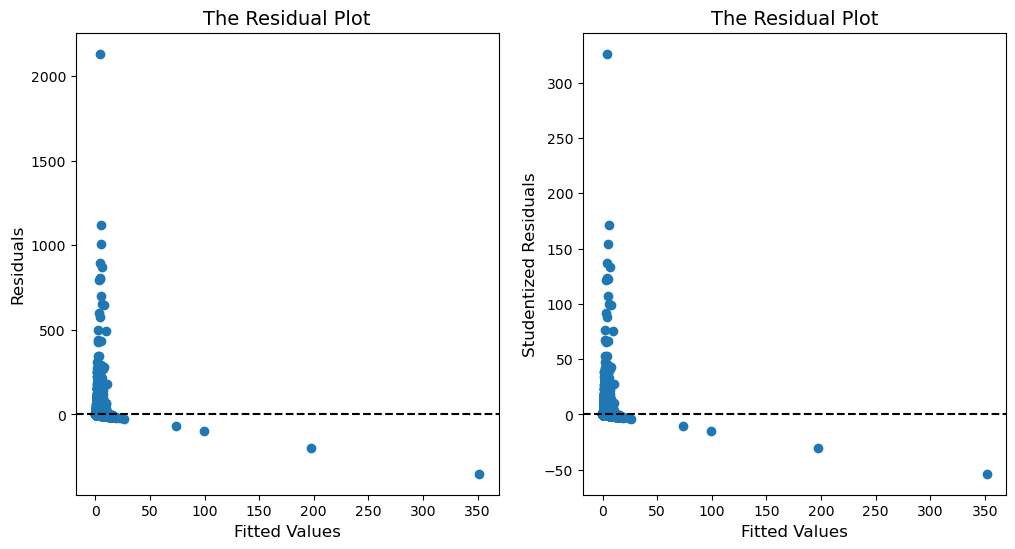

In [37]:
trainX = trainXs[-1]
trainY = trainYs[-1]

model = sm.OLS(trainY, trainX)
res = model.fit()
residuals = res.resid
residualSE = np.sqrt(np.sum(np.power(res.resid,2))/(len(trainX) - len(trainX.columns)))
studentizedResiduals = residuals/residualSE

fig, ax = plt.subplots(1,2,figsize = (12,6))

ax[0].scatter(res.predict(trainX), residuals)
ax[0].axhline(0,c='k', ls = '--')
ax[0].set_ylabel("Residuals", fontsize=12)
ax[0].set_xlabel("Fitted Values", fontsize=12)
ax[0].set_title(f"The Residual Plot", fontsize=14)


ax[1].scatter(res.predict(trainX), studentizedResiduals)
ax[1].axhline(0,c='k', ls = '--')
ax[1].set_ylabel("Studentized Residuals", fontsize=12)
ax[1].set_xlabel("Fitted Values", fontsize=12)
ax[1].set_title(f"The Residual Plot", fontsize=14)

plt.show()

There are quite a bit of outliers in the data. We will use regularization to decrease the effect of outliers on our model.

### Regularization

We will write some helper functions to help us with regularization

In [41]:
def getCrossValRegMSE(trainXs, trainYs, validXs, validYs, weight, alpha):

    ## Compute the cross validation error for regualrized linear regression when the parameter is alpha.
    ## Lasso regularization is used when weight is 1, and Ridge regularization is used when weight is 0.
    
    MSEs = np.zeros(4)

    labels = list(trainXs[-1].columns)    
    
    alpha = [alpha for _ in range(len(labels))]
    alpha[labels.index("INTERCEPT")] = 0.0
    alpha = np.array(alpha)
    
    for i in range(4):
        trainX, trainY, validX, validY = trainXs[i].astype(float), trainYs[i].astype(float), validXs[i].astype(float), validYs[i].astype(float)
        means = {}
        sds = {}

        continuousCols = ["LATITUDE", "LONGITUDE", "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES", "PRCP", "SNOW", "TOBS"]

        for col in continuousCols:
            if col not in trainX.columns:
                continue
            means[col] = np.mean(trainX[col].values)
            sds[col] = np.sqrt(np.sum(np.power(trainX[col].values - means[col],2)))
        for col in continuousCols:
            if col not in trainX.columns:
                continue

            trainX.loc[:,col] = (trainX[col] - means[col])/sds[col]
            validX.loc[:,col] = (validX[col] - means[col])/sds[col]
        model = sm.OLS(trainY, trainX)

        results = model.fit_regularized(method = "elastic_net", alpha = alpha, L1_wt = weight)
        preds = results.predict(validX)
        MSEs[i] = np.mean(np.power(validY.values-preds, 2))
    
    return np.mean(MSEs), results.params


def findBestIndex(errors):

    ## Find the index with the smaller error in errors
    
    i = 0
    cur = float("inf")
    curInd = -1
    
    for err in errors:
        if err >= cur:
            i += 1
            continue
        cur = err
        curInd = i
        i +=1
    return curInd

def getOptimalParam(trainXs, trainYs, validXs, validYs, weight, alphas):

    ## Find the optimal parameter for regularization

    n = len(alphas)
    cv_error = np.zeros(n)
    regCoeffs = [ ]
    
    for i in range(n):

        ## Lasso regulariation takes quite a bit of time...
        
        if weight == 1:
            print(i)

        ##
        
        error, coeffs = getCrossValRegMSE(trainXs, trainYs, validXs, validYs, weight, alphas[i])
        cv_error[i] = error
        regCoeffs.append(coeffs)

    bestInd = findBestIndex(cv_error)

    return alphas[bestInd], regCoeffs[bestInd], cv_error[bestInd]

First, we will use Lasso regularization. This will have the added advantage of performing variable selection.

In [43]:
alphas = np.logspace(-6, -2, num = 20)
alpha, coeffs, error = getOptimalParam(trainXs, trainYs, validXs, validYs, 1, alphas)

print(f"The optimal parameter value is {alpha} with a cross validation error of {error}")
print("The optimal regularized coefficients are")
print(coeffs)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
The optimal parameter value is 0.0008858667904100823 with a cross validation error of 42.532020603230926
The optimal regularized coefficients are
IBA CODE                        -0.045113
USFWS CODE                      -0.298930
OBSERVATION DATE                 0.000000
DURATION MINUTES               105.214631
PRCP                             0.000000
SNOW                             0.000000
TOBS                             0.000000
OBSERVATION TYPE_Area            4.080924
OBSERVATION TYPE_Historical      1.238832
OBSERVATION TYPE_Stationary      1.575279
OBSERVATION TYPE_Traveling       1.558053
INTERCEPT                        0.246102
SIN                             -0.123059
COS                             -0.089718
dtype: float64


Second, let's try using linear regression on the variables selected by lasso regularization.

In [45]:
sigCols = list(coeffs[coeffs != 0].index)

X = data.copy()

X["SIN"] = np.sin(data["OBSERVATION DATE"].to_numpy()*2*np.pi*(j+1)/365)
X["COS"] = np.cos(data["OBSERVATION DATE"].to_numpy()*2*np.pi*(j+1)/365)

X = X[sigCols]

trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y,Dates)

In [46]:
print(f"The cross validated error is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validated error is 43.298661005582375


Third, we will use Ridge regularization.

In [48]:
X = data.drop(["OBSERVATION COUNT"] + bCols + noInfoCols + collinCols, axis = 1)

X["SIN"] = np.sin(data["OBSERVATION DATE"].to_numpy()*2*np.pi*(j+1)/365)
X["COS"] = np.cos(data["OBSERVATION DATE"].to_numpy()*2*np.pi*(j+1)/365)

trainXs, trainYs, validXs, validYs, _, _ = getCrossValSplit(X,Y,Dates)

alphas = np.logspace(-8, -2, num = 100)
alpha, coeffs, error = getOptimalParam(trainXs, trainYs, validXs, validYs, 0, alphas)

print(f"The optimal parameter value is {alpha} with a cross validation error of {error}")
print("The optimal regularized coefficients are")
print(coeffs)

The optimal parameter value is 3.5111917342151275e-06 with a cross validation error of 42.515183074440436
The optimal regularized coefficients are
[-6.64304064e-02 -3.41410797e-01 -3.67566638e+01  2.09895645e+02
  3.98657249e+00  4.61205048e+01  9.14245183e+00  2.36351356e+00
 -2.80248006e-01 -2.32800259e-01 -2.73916585e-01  2.07032407e+00
 -1.22257949e-01 -8.25915450e-02]


Finally, let's see what happens when we use Ridge regularization on the selected variables.

In [50]:
X = data.copy()

X["SIN"] = np.sin(data["OBSERVATION DATE"].to_numpy()*2*np.pi*(j+1)/365)
X["COS"] = np.cos(data["OBSERVATION DATE"].to_numpy()*2*np.pi*(j+1)/365)

X = X[sigCols]

trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y,Dates)

alphas = np.logspace(-8, -2, num = 100)
alpha, coeffs, error = getOptimalParam(trainXs, trainYs, validXs, validYs, 0, alphas)

print(f"The optimal parameter value is {alpha} with a cross validation error of {error}")
print("The optimal regularized coefficients are")
print(coeffs)

The optimal parameter value is 2.656087782946684e-06 with a cross validation error of 42.43990870094965
The optimal regularized coefficients are
[-7.65385428e-02 -3.42782048e-01  2.54455163e+02  2.47217098e+00
 -1.38268218e-01 -8.16548897e-02 -1.43291827e-01  1.93382355e+00
 -1.13976077e-01 -9.15808259e-02]
